##  Historical VaR and CVaR

# Advanced Analytics + Risk Metrics

## Objective

This analysis extends the mutual fund analytics project by evaluating
historical downside risk, risk-adjusted performance, investor behaviour,
SIP continuity and fund-level recommendations.

The analysis covers:

1. Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR)
2. 90-day rolling Sharpe ratio
3. Investor cohort analysis
4. SIP continuity and at-risk investors
5. Risk-based fund recommendations
6. Portfolio concentration using HHI
7. Advanced business insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
base_path = r"D:\MutualFundAnalytics\data\processed"

print(os.listdir(base_path))

['01_fund_master_clean.csv', '02_nav_history_clean.csv', '03_aum_by_fund_house_clean.csv', '04_monthly_sip_inflows_clean.csv', '05_category_inflows_clean.csv', '06_industry_folio_count_clean.csv', '07_scheme_performance_clean.csv', '08_investor_transactions_clean.csv', '09_portfolio_holdings_clean.csv', '10_benchmark_indices_clean.csv']


In [3]:
fund_master = pd.read_csv(
    os.path.join(base_path, "01_fund_master_clean.csv")
)

nav = pd.read_csv(
    os.path.join(base_path, "02_nav_history_clean.csv")
)

print("Fund Master shape:", fund_master.shape)
print("NAV History shape:", nav.shape)

Fund Master shape: (40, 15)
NAV History shape: (46000, 3)


In [4]:
print("Fund Master columns:")
print(fund_master.columns.tolist())

print("\nNAV History columns:")
print(nav.columns.tolist())

Fund Master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV History columns:
['amfi_code', 'date', 'nav']


In [5]:
print("NAV History:")
display(nav.head())

print("\nFund Master:")
display(fund_master.head())

NAV History:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639



Fund Master:


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [6]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print("Minimum date:", nav["date"].min())
print("Maximum date:", nav["date"].max())
print("Number of schemes:", nav["amfi_code"].nunique())
print("Number of NAV records:", len(nav))

Minimum date: 2022-01-03 00:00:00
Maximum date: 2026-05-29 00:00:00
Number of schemes: 40
Number of NAV records: 46000


In [7]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

display(
    nav[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(10)
)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
print("Total NAV records:", len(nav))
print(
    "Missing daily returns:",
    nav["daily_return"].isna().sum()
)

print(
    "Valid daily returns:",
    nav["daily_return"].notna().sum()
)

Total NAV records: 46000
Missing daily returns: 40
Valid daily returns: 45960


In [9]:
# Historical VaR (95%) and CVaR for all 40 schemes

def calculate_var_cvar(group):
    returns = group["daily_return"].dropna()

    var_95 = returns.quantile(0.05)

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    return pd.Series({
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })


var_cvar = (
    nav.groupby("amfi_code")
       .apply(calculate_var_cvar)
       .reset_index()
)

# Add scheme information
fund_info = fund_master[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "sub_category",
        "risk_category"
    ]
].drop_duplicates("amfi_code")

var_cvar_report = var_cvar.merge(
    fund_info,
    on="amfi_code",
    how="left"
)

# Arrange columns
var_cvar_report = var_cvar_report[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "sub_category",
        "risk_category",
        "VaR_95",
        "CVaR_95"
    ]
]

# Save deliverable
var_cvar_report.to_csv(
    r"D:\MutualFundAnalytics\var_cvar_report.csv",
    index=False
)

print("VaR/CVaR calculated for:", len(var_cvar_report), "schemes")
print("Saved: D:\\MutualFundAnalytics\\var_cvar_report.csv")

VaR/CVaR calculated for: 40 schemes
Saved: D:\MutualFundAnalytics\var_cvar_report.csv


# Rolling 90-Day Sharpe Ratio

In [10]:
# 90-day rolling Sharpe ratio

nav["rolling_sharpe_90"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(
           lambda x: (
               x.rolling(90).mean()
               / x.rolling(90).std()
           ) * np.sqrt(252)
       )
)

print("Rolling 90-day Sharpe calculated.")

Rolling 90-day Sharpe calculated.


In [11]:
# Find the five key funds

key_search = fund_master[
    fund_master["scheme_name"].str.contains(
        "SBI Bluechip|ICICI Bluechip|Nippon.*Large|Axis Bluechip|Kotak Bluechip",
        case=False,
        na=False,
        regex=True
    )
]

display(
    key_search[
        ["amfi_code", "scheme_name", "fund_house"]
    ]
)

,amfi_code,scheme_name,fund_house
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
16,118633,Nippon India Large Cap Fund - Direct - Growth,Nippon India MF
20,120841,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF
24,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund
25,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund


In [13]:
fund_master[
    fund_master["scheme_name"].str.contains(
        "ICICI",
        case=False,
        na=False
    )
][
    ["amfi_code", "scheme_name", "fund_house"]
]

,amfi_code,scheme_name,fund_house
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
13,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF


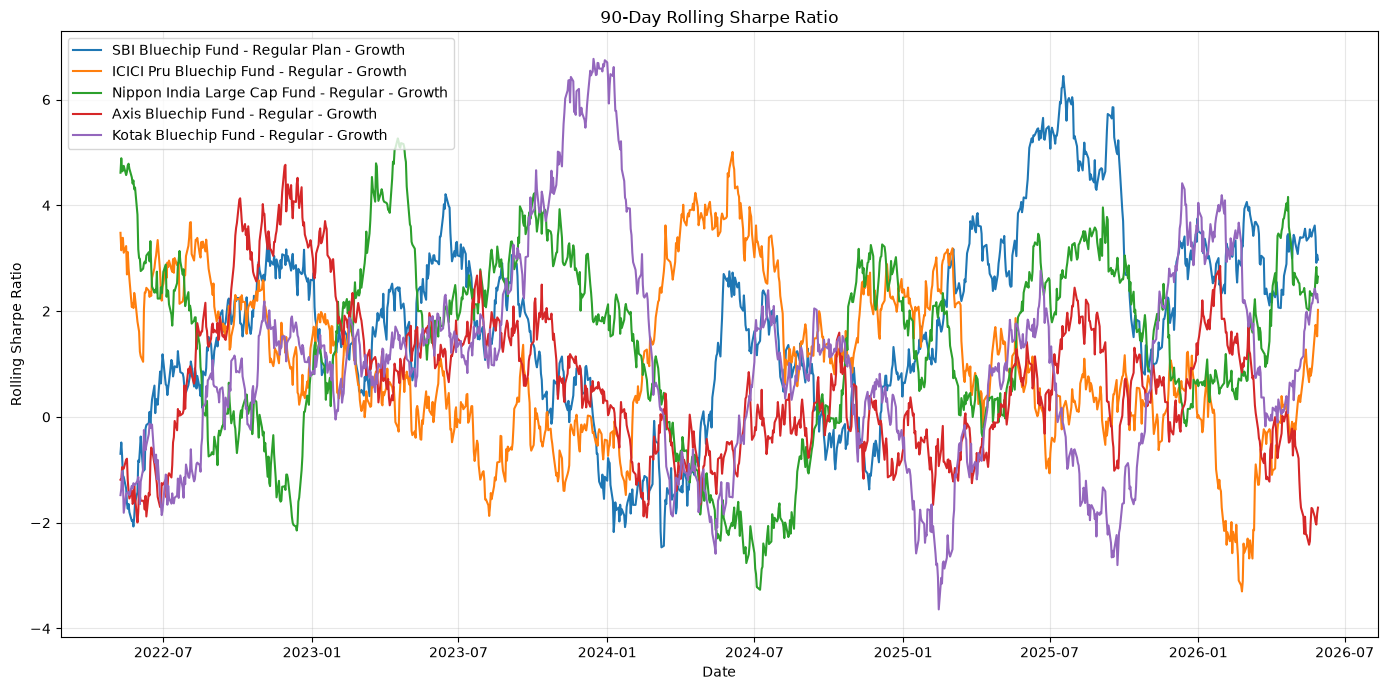

Saved: D:\MutualFundAnalytics\rolling_sharpe_chart.png


In [14]:
key_funds = [
    119551,   # SBI Bluechip
    120503,   # ICICI Pru Bluechip
    118632,   # Nippon India Large Cap
    119092,   # Axis Bluechip
    120841    # Kotak Bluechip
]

plot_data = nav[
    nav["amfi_code"].isin(key_funds)
].copy()

plot_data = plot_data.merge(
    fund_info[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

plt.figure(figsize=(14, 7))

for code in key_funds:

    temp = plot_data[
        plot_data["amfi_code"] == code
    ]

    if len(temp) == 0:
        continue

    plt.plot(
        temp["date"],
        temp["rolling_sharpe_90"],
        label=temp["scheme_name"].iloc[0]
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    r"D:\MutualFundAnalytics\rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: D:\\MutualFundAnalytics\\rolling_sharpe_chart.png")

##  Investor Cohort Analysis



Investor cohort analysis groups investors according to the year in which
they made their first recorded transaction. This helps compare the
investment behaviour of investors who entered the mutual fund market in
different years.

For each cohort, the analysis measures average SIP amount, total invested
amount, number of SIP transactions, number of investors, and the most
preferred fund.

In [15]:
investor = pd.read_csv(
    os.path.join(
        base_path,
        "08_investor_transactions_clean.csv"
    )
)

print("Investor transaction shape:", investor.shape)
print("Columns:")
print(investor.columns.tolist())

Investor transaction shape: (32778, 13)
Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [16]:
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

print("Minimum transaction date:",
      investor["transaction_date"].min())

print("Maximum transaction date:",
      investor["transaction_date"].max())

Minimum transaction date: 2024-01-01 00:00:00
Maximum transaction date: 2025-05-30 00:00:00


In [17]:
first_transaction = (
    investor
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

investor = investor.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

print("Investor cohorts created.")

display(
    investor[
        [
            "investor_id",
            "transaction_date",
            "cohort_year"
        ]
    ].head(10)
)

Investor cohorts created.


,investor_id,transaction_date,cohort_year
0,INV003054,2024-01-01,2024
1,INV002952,2024-01-01,2024
2,INV003420,2024-01-01,2024
3,INV003436,2024-01-01,2024
4,INV004691,2024-01-01,2024
5,INV001497,2024-01-01,2024
6,INV000786,2024-01-01,2024
7,INV000616,2024-01-01,2024
8,INV003670,2024-01-01,2024
9,INV002054,2024-01-01,2024


In [18]:
sip = investor[
    investor["transaction_type"]
    .astype(str)
    .str.strip()
    .str.upper()
    == "SIP"
].copy()

print("Total SIP transactions:", len(sip))
print("Unique SIP investors:",
      sip["investor_id"].nunique())

Total SIP transactions: 19716
Unique SIP investors: 4762


In [19]:
cohort_summary = (
    sip
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        sip_transactions=("amount_inr", "count"),
        unique_investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,sip_transactions,unique_investors
0,2024,10996.885825,214978121,19549,4624
1,2025,13505.209581,2255370,167,138


In [20]:
cohort_fund_counts = (
    sip
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(
        name="transaction_count"
    )
)

cohort_fund_counts = (
    cohort_fund_counts
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

In [21]:
cohort_top_funds = cohort_fund_counts.merge(
    fund_info[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

cohort_top_funds

,cohort_year,amfi_code,transaction_count,scheme_name
0,2024,120504,536,ICICI Pru Bluechip Fund - Direct - Growth
1,2025,119599,8,SBI Small Cap Fund - Direct Plan - Growth


In [22]:
cohort_analysis = cohort_summary.merge(
    cohort_top_funds[
        [
            "cohort_year",
            "amfi_code",
            "scheme_name",
            "transaction_count"
        ]
    ],
    on="cohort_year",
    how="left"
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,sip_transactions,unique_investors,amfi_code,scheme_name,transaction_count
0,2024,10996.885825,214978121,19549,4624,120504,ICICI Pru Bluechip Fund - Direct - Growth,536
1,2025,13505.209581,2255370,167,138,119599,SBI Small Cap Fund - Direct Plan - Growth,8


In [23]:
print("Cohort with highest total investment:")

display(
    cohort_analysis.loc[
        cohort_analysis["total_invested"].idxmax()
    ]
)

print("\nCohort with highest average SIP amount:")

display(
    cohort_analysis.loc[
        cohort_analysis["avg_sip_amount"].idxmax()
    ]
)

Cohort with highest total investment:


cohort_year                                               2024
avg_sip_amount                                    10996.885825
total_invested                                       214978121
sip_transactions                                         19549
unique_investors                                          4624
amfi_code                                               120504
scheme_name          ICICI Pru Bluechip Fund - Direct - Growth
transaction_count                                          536
Name: 0, dtype: object


Cohort with highest average SIP amount:


cohort_year                                               2025
avg_sip_amount                                    13505.209581
total_invested                                         2255370
sip_transactions                                           167
unique_investors                                           138
amfi_code                                               119599
scheme_name          SBI Small Cap Fund - Direct Plan - Growth
transaction_count                                            8
Name: 1, dtype: object

##  SIP Continuity Analysis

SIP continuity analysis evaluates how regularly investors continue their
Systematic Investment Plan contributions. The analysis focuses on
investors with at least six SIP transactions, since a minimum number of
transactions is required to meaningfully evaluate their investment
pattern.

The average number of days between consecutive SIP transactions is
calculated for each eligible investor. Investors with an average gap
greater than 35 days are classified as "at-risk", indicating a relatively
irregular SIP contribution pattern.

In [24]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
).copy()

print("SIP data sorted successfully.")

SIP data sorted successfully.


In [25]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

display(
    sip[
        [
            "investor_id",
            "transaction_date",
            "gap_days"
        ]
    ].head(15)
)

,investor_id,transaction_date,gap_days
19621,INV000001,2024-11-04,NaN
24448,INV000001,2025-01-19,76.0
5650,INV000002,2024-03-29,NaN
16803,INV000002,2024-09-21,176.0
31881,INV000002,2025-05-17,238.0
12652,INV000003,2024-07-16,NaN
27622,INV000003,2025-03-11,238.0
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0


In [26]:
sip_counts = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

print("Total SIP investors:", len(sip_counts))

print(
    "Investors with 6+ SIP transactions:",
    (sip_counts["sip_count"] >= 6).sum()
)

Total SIP investors: 4762
Investors with 6+ SIP transactions: 1362


In [27]:
eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
].copy()

print(
    "Eligible investors:",
    len(eligible_investors)
)

Eligible investors: 1362


In [28]:
sip_continuity = (
    sip[
        sip["investor_id"].isin(
            eligible_investors["investor_id"]
        )
    ]
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

sip_continuity.head(10)

,investor_id,sip_count,avg_gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000
5,INV000013,7,55.333333
6,INV000014,7,75.333333
7,INV000023,8,58.571429
8,INV000028,6,93.600000
9,INV000029,7,60.666667


In [29]:
sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "at-risk",
    "regular"
)

sip_continuity.head(10)

,investor_id,sip_count,avg_gap_days,status
0,INV000004,6,85.400000,at-risk
1,INV000008,6,70.400000,at-risk
2,INV000010,6,64.800000,at-risk
3,INV000011,7,40.166667,at-risk
4,INV000012,8,57.000000,at-risk
5,INV000013,7,55.333333,at-risk
6,INV000014,7,75.333333,at-risk
7,INV000023,8,58.571429,at-risk
8,INV000028,6,93.600000,at-risk
9,INV000029,7,60.666667,at-risk


In [30]:
total_eligible = len(sip_continuity)

at_risk_count = (
    sip_continuity["status"] == "at-risk"
).sum()

regular_count = (
    sip_continuity["status"] == "regular"
).sum()

at_risk_pct = (
    at_risk_count / total_eligible * 100
)

regular_pct = (
    regular_count / total_eligible * 100
)

print("Eligible investors:", total_eligible)
print("Regular investors:", regular_count)
print("At-risk investors:", at_risk_count)
print("Regular SIP rate:", round(regular_pct, 2), "%")
print("At-risk rate:", round(at_risk_pct, 2), "%")

Eligible investors: 1362
Regular investors: 30
At-risk investors: 1332
Regular SIP rate: 2.2 %
At-risk rate: 97.8 %


In [31]:
sip_continuity.sort_values(
    "avg_gap_days",
    ascending=False
).head(10)

,investor_id,sip_count,avg_gap_days,status
506,INV001890,6,102.6,at-risk
323,INV001156,6,102.4,at-risk
1188,INV004296,6,102.2,at-risk
910,INV003325,6,101.0,at-risk
150,INV000522,6,100.8,at-risk
183,INV000608,6,100.2,at-risk
503,INV001883,6,99.2,at-risk
576,INV002166,6,99.2,at-risk
380,INV001367,6,99.0,at-risk
406,INV001491,6,98.8,at-risk


In [32]:
sip_continuity.to_csv(
    r"D:\MutualFundAnalytics\sip_continuity_report.csv",
    index=False
)

print(
    "Saved: D:\\MutualFundAnalytics\\sip_continuity_report.csv"
)

Saved: D:\MutualFundAnalytics\sip_continuity_report.csv


##  Simple Fund Recommender

A simple risk-based fund recommender was developed using investor risk
appetite and historical Sharpe ratio. Investors can select Low, Moderate,
or High risk appetite. The system then filters funds belonging to the
matching risk category and ranks them according to their Sharpe ratio.

The top three funds are returned as recommendations. This approach
provides a simple and transparent recommendation method based on
risk suitability and historical risk-adjusted performance.

In [33]:
scheme_sharpe = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(
           mean_return="mean",
           std_return="std"
       )
       .reset_index()
)

scheme_sharpe["sharpe_ratio"] = (
    scheme_sharpe["mean_return"]
    / scheme_sharpe["std_return"]
) * np.sqrt(252)

scheme_sharpe.head()

,amfi_code,mean_return,std_return,sharpe_ratio
0,100016,0.000142,0.009164,0.245276
1,100025,0.000170,0.002460,1.097333
2,100033,0.001080,0.011929,1.436947
3,101206,0.000852,0.009177,1.473390
4,101207,0.000424,0.016251,0.414625


In [34]:
recommender_data = scheme_sharpe.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "risk_category"
        ]
    ],
    on="amfi_code",
    how="left"
)

recommender_data = recommender_data[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "risk_category",
        "sharpe_ratio"
    ]
]

recommender_data.head()

,amfi_code,scheme_name,fund_house,category,risk_category,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Moderate,0.245276
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,Low,1.097333
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,High,1.436947
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Moderate,1.473390
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Very High,0.414625


In [35]:
print(
    recommender_data["risk_category"]
    .value_counts()
)

risk_category
Moderate           16
High                8
Low                 6
Very High           6
Moderately High     4
Name: count, dtype: int64


In [36]:
def recommend_funds(risk_appetite):

    risk_appetite = (
        risk_appetite
        .strip()
        .title()
    )

    if risk_appetite == "Low":
        matching_risk = ["Low"]

    elif risk_appetite == "Moderate":
        matching_risk = ["Moderate"]

    elif risk_appetite == "High":
        matching_risk = ["High", "Very High"]

    else:
        print(
            "Invalid risk appetite. "
            "Please enter Low, Moderate, or High."
        )
        return pd.DataFrame()

    recommendations = (
        recommender_data[
            recommender_data["risk_category"]
            .isin(matching_risk)
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
        .copy()
    )

    return recommendations[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "risk_category",
            "sharpe_ratio"
        ]
    ]

In [37]:
recommend_funds("Low")

,amfi_code,scheme_name,fund_house,category,risk_category,sharpe_ratio
27,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Debt,Low,13.655946
31,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Debt,Low,12.573992
5,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt,Low,12.019194


In [38]:
recommend_funds("Moderate")

,amfi_code,scheme_name,fund_house,category,risk_category,sharpe_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Moderate,1.906241
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Moderate,1.681289
9,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,Moderate,1.541077


In [39]:
recommend_funds("High")

,amfi_code,scheme_name,fund_house,category,risk_category,sharpe_ratio
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,High,1.602702
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,High,1.517047
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,High,1.498398


In [40]:
risk = input(
    "Enter risk appetite (Low / Moderate / High): "
)

recommendations = recommend_funds(risk)

display(recommendations)

,amfi_code,scheme_name,fund_house,category,risk_category,sharpe_ratio
27,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Debt,Low,13.655946
31,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Debt,Low,12.573992
5,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt,Low,12.019194


In [41]:
risk = input(
    "Enter risk appetite (Low / Moderate / High): "
)

recommendations = recommend_funds(risk)

display(recommendations)

,amfi_code,scheme_name,fund_house,category,risk_category,sharpe_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Moderate,1.906241
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Moderate,1.681289
9,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,Moderate,1.541077


In [42]:
risk = input(
    "Enter risk appetite (Low / Moderate / High): "
)

recommendations = recommend_funds(risk)

display(recommendations)

,amfi_code,scheme_name,fund_house,category,risk_category,sharpe_ratio
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,High,1.602702
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,High,1.517047
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,High,1.498398


In [43]:
recommendations.to_csv(
    r"D:\MutualFundAnalytics\fund_recommendations.csv",
    index=False
)

print(
    "Saved: D:\\MutualFundAnalytics\\fund_recommendations.csv"
)

Saved: D:\MutualFundAnalytics\fund_recommendations.csv


## Sector HHI Concentration

Portfolio concentration was evaluated using the Herfindahl-Hirschman
Index (HHI). The HHI is calculated as the sum of squared portfolio
weights across sectors. A higher HHI indicates greater concentration
in fewer sectors, while a lower HHI indicates greater diversification
across sectors.

In [44]:
holdings = pd.read_csv(
    os.path.join(
        base_path,
        "09_portfolio_holdings_clean.csv"
    )
)

print("Holdings shape:", holdings.shape)
print("Holdings columns:")
print(holdings.columns.tolist())

display(holdings.head())

Holdings shape: (322, 8)
Holdings columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [45]:
holdings["weight_pct"] = pd.to_numeric(
    holdings["weight_pct"],
    errors="coerce"
)

holdings = holdings.dropna(
    subset=["weight_pct"]
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [46]:
sector_weights = (
    holdings
    .groupby(
        ["amfi_code", "sector"]
    )["weight_pct"]
    .sum()
    .reset_index()
)

sector_weights.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [47]:
sector_weights["weight_decimal"] = (
    sector_weights["weight_pct"] / 100
)

sector_weights["weight_square"] = (
    sector_weights["weight_decimal"] ** 2
)

hhi = (
    sector_weights
    .groupby("amfi_code")["weight_square"]
    .sum()
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [48]:
hhi_report = hhi.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

hhi_report = hhi_report[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "HHI"
    ]
]

hhi_report.head()

,amfi_code,scheme_name,fund_house,category,HHI
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,0.180588
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.227647
2,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.180042
3,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.222727
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity,0.180712


In [49]:
most_concentrated = (
    hhi_report
    .sort_values(
        "HHI",
        ascending=False
    )
)

most_concentrated.head(10)

,amfi_code,scheme_name,fund_house,category,HHI
11,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity,0.296769
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.254992
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity,0.253155
6,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,0.251383
32,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.241077
21,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.238695
10,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity,0.237497
18,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.232361
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Equity,0.231464
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.227647


In [50]:
most_diversified = (
    hhi_report
    .sort_values(
        "HHI",
        ascending=True
    )
)

most_diversified.head(10)

,amfi_code,scheme_name,fund_house,category,HHI
5,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,0.124020
25,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.136206
15,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.142491
14,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.159582
9,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,0.160299
24,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.162062
26,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Equity,0.172411
13,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.175100
2,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.180042
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,0.180588


In [51]:
hhi_report.to_csv(
    r"D:\MutualFundAnalytics\hhi_report.csv",
    index=False
)

print(
    "Saved: D:\\MutualFundAnalytics\\hhi_report.csv"
)

Saved: D:\MutualFundAnalytics\hhi_report.csv


##  Advanced Insights

The advanced analytics provide several useful observations about fund
risk, risk-adjusted performance, investor behaviour, SIP continuity,
and portfolio concentration.

In [52]:
print("========== INSIGHT 1: VaR / CVaR ==========")

highest_var = var_cvar_report.sort_values(
    "VaR_95",
    ascending=True
).iloc[0]

highest_cvar = var_cvar_report.sort_values(
    "CVaR_95",
    ascending=True
).iloc[0]

print(
    "Highest downside risk by VaR:",
    highest_var["scheme_name"]
)
print(
    "VaR 95%:",
    round(highest_var["VaR_95"], 4)
)

print(
    "Highest tail risk by CVaR:",
    highest_cvar["scheme_name"]
)
print(
    "CVaR 95%:",
    round(highest_cvar["CVaR_95"], 4)
)


print("\n========== INSIGHT 2: INVESTOR COHORT ==========")

largest_cohort = cohort_analysis.sort_values(
    "total_invested",
    ascending=False
).iloc[0]

highest_sip_cohort = cohort_analysis.sort_values(
    "avg_sip_amount",
    ascending=False
).iloc[0]

print(
    "Highest total investment cohort:",
    int(largest_cohort["cohort_year"])
)
print(
    "Total invested:",
    round(largest_cohort["total_invested"], 2)
)

print(
    "Highest average SIP cohort:",
    int(highest_sip_cohort["cohort_year"])
)
print(
    "Average SIP amount:",
    round(highest_sip_cohort["avg_sip_amount"], 2)
)


print("\n========== INSIGHT 3: SIP CONTINUITY ==========")

print(
    "Eligible investors:",
    total_eligible
)

print(
    "Regular investors:",
    regular_count
)

print(
    "At-risk investors:",
    at_risk_count
)

print(
    "Regular SIP rate:",
    round(regular_pct, 2),
    "%"
)

print(
    "At-risk SIP rate:",
    round(at_risk_pct, 2),
    "%"
)


print("\n========== INSIGHT 4: SHARPE ==========")

best_sharpe = recommender_data.sort_values(
    "sharpe_ratio",
    ascending=False
).iloc[0]

print(
    "Highest historical Sharpe ratio:",
    best_sharpe["scheme_name"]
)

print(
    "Sharpe ratio:",
    round(best_sharpe["sharpe_ratio"], 4)
)


print("\n========== INSIGHT 5: HHI ==========")

highest_hhi = hhi_report.sort_values(
    "HHI",
    ascending=False
).iloc[0]

lowest_hhi = hhi_report.sort_values(
    "HHI",
    ascending=True
).iloc[0]

print(
    "Most concentrated fund:",
    highest_hhi["scheme_name"]
)

print(
    "HHI:",
    round(highest_hhi["HHI"], 4)
)

print(
    "Most diversified fund:",
    lowest_hhi["scheme_name"]
)

print(
    "HHI:",
    round(lowest_hhi["HHI"], 4)
)

========== INSIGHT 1: VaR / CVaR ==========
Highest downside risk by VaR: SBI Small Cap Fund - Direct Plan - Growth
VaR 95%: -0.0269
Highest tail risk by CVaR: ABSL Small Cap Fund - Regular - Growth
CVaR 95%: -0.0325

========== INSIGHT 2: INVESTOR COHORT ==========
Highest total investment cohort: 2024
Total invested: 214978121
Highest average SIP cohort: 2025
Average SIP amount: 13505.21

========== INSIGHT 3: SIP CONTINUITY ==========
Eligible investors: 1362
Regular investors: 30
At-risk investors: 1332
Regular SIP rate: 2.2 %
At-risk SIP rate: 97.8 %

========== INSIGHT 4: SHARPE ==========
Highest historical Sharpe ratio: ICICI Pru Liquid Fund - Regular - Growth
Sharpe ratio: 13.6559

========== INSIGHT 5: HHI ==========
Most concentrated fund: Axis Bluechip Fund - Regular - Growth
HHI: 0.2968
Most diversified fund: UTI Mid Cap Fund - Regular - Growth
HHI: 0.124


## Advanced Insights

### 1. Fund downside risk

Historical VaR and CVaR analysis shows that SBI Small Cap Fund - Direct Plan - Growth recorded the highest downside risk based on the 95% VaR measure, with a VaR of approximately -2.69%. The most severe average loss among observations beyond the VaR threshold was observed for ABSL Small Cap Fund - Regular - Growth, with a CVaR of approximately -3.25%. These results highlight the higher downside risk associated with small-cap funds in the analysed dataset.

### 2. Investor cohort behaviour

The 2024 investor cohort recorded the highest total investment, with approximately ₹21.50 crore invested through the analysed transactions. The 2025 cohort recorded the highest average SIP contribution, at approximately ₹13,505 per SIP transaction. This indicates that the amount invested and the average contribution size can differ across investor entry cohorts.

### 3. SIP continuity

Among investors with at least six SIP transactions, 1,362 investors were identified for the continuity analysis. Of these, 30 investors (2.2%) were classified as regular investors, while 1,332 investors (97.8%) were classified as at-risk because their average gap between SIP transactions exceeded 35 days. This indicates a high level of irregular SIP contribution behaviour in the analysed dataset and highlights a potential area for investor retention and engagement.

### 4. Risk-adjusted performance

The highest historical Sharpe ratio in the analysed dataset was recorded by ICICI Pru Liquid Fund - Regular - Growth, with a Sharpe ratio of approximately 13.66. This indicates a very strong historical return relative to volatility under the calculated Sharpe measure. However, this result should be interpreted within the fund's category, since liquid funds generally have substantially lower volatility than equity funds.

### 5. Portfolio concentration

The highest sector concentration was observed in Axis Bluechip Fund - Regular - Growth, with an HHI of 0.2968. The lowest concentration was observed in UTI Mid Cap Fund - Regular - Growth, with an HHI of 0.1240. Therefore, Axis Bluechip had a more concentrated sector allocation, while UTI Mid Cap showed greater diversification across sectors based on the available portfolio holdings.